In [1]:
import os
os.chdir(r'C:\Users\rdama\OneDrive\Desktop\2026 projects\soundmetrics')
print("Working directory:", os.getcwd())

Working directory: C:\Users\rdama\OneDrive\Desktop\2026 projects\soundmetrics


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi']     = 120
plt.rcParams['figure.figsize'] = (12, 5)
np.random.seed(42)

os.makedirs('data/charts', exist_ok=True)
os.makedirs('data/exports', exist_ok=True)

print('✅ All libraries imported!')

✅ All libraries imported!


In [3]:
CLEAN_DIR   = 'data/cleaned'
EXPORTS_DIR = 'data/exports'

users   = pd.read_csv(f'{CLEAN_DIR}/users_clean.csv',            parse_dates=['signup_date'])
events  = pd.read_csv(f'{CLEAN_DIR}/listening_events_clean.csv', parse_dates=['event_date'])
pays    = pd.read_csv(f'{CLEAN_DIR}/payments_clean.csv',         parse_dates=['payment_date'])
subs    = pd.read_csv(f'{CLEAN_DIR}/subscriptions_clean.csv')
tickets = pd.read_csv(f'{CLEAN_DIR}/support_tickets_clean.csv')

print('Tables loaded:')
for name, df in [('users',users),('events',events),('payments',pays),
                  ('subscriptions',subs),('tickets',tickets)]:
    print(f'  {name:<20} {len(df):>10,} rows')

Tables loaded:
  users                    99,500 rows
  events                1,186,834 rows
  payments                 72,730 rows
  subscriptions           100,000 rows
  tickets                  20,000 rows


In [4]:
today = pd.Timestamp.today().normalize()

listening_features = (
    events.groupby('user_id')
    .agg(
        total_plays          = ('event_id',            'count'),
        avg_listen_duration  = ('listen_duration_sec', 'mean'),
        skip_rate            = ('is_skip',             'mean'),
        unique_genres        = ('genre',               'nunique'),
        repeat_rate          = ('is_repeat_listen',    'mean'),
        last_play_date       = ('event_date',          'max')
    )
    .reset_index()
)
listening_features['days_since_last_play'] = (
    (today - listening_features['last_play_date']).dt.days
)
listening_features['skip_rate']   = (listening_features['skip_rate']   * 100).round(2)
listening_features['repeat_rate'] = (listening_features['repeat_rate'] * 100).round(2)
listening_features['avg_listen_duration'] = listening_features['avg_listen_duration'].round(1)

print(f'Listening features built for {len(listening_features):,} users')
print(listening_features.head(3).to_string())

Listening features built for 84,243 users
   user_id  total_plays  avg_listen_duration  skip_rate  unique_genres  repeat_rate last_play_date  days_since_last_play
0        1            3                135.3       0.00              3          0.0     2023-08-09                   940
1        2            1                 79.0       0.00              1          0.0     2020-03-25                  2172
2        4            7                143.9      28.57              7          0.0     2024-12-13                   448


In [5]:
payment_features = (
    pays.groupby('user_id')
    .agg(
        lifetime_revenue = ('amount', lambda x: x[pays.loc[x.index, 'status'] == 'Success'].sum()),
        payment_count    = ('payment_id', 'count'),
        failed_payments  = ('status', lambda x: (x == 'Failed').sum())
    )
    .reset_index()
)
payment_features['lifetime_revenue'] = payment_features['lifetime_revenue'].round(2)

print(f'Payment features built for {len(payment_features):,} users')
print(payment_features.head(3).to_string())

Payment features built for 40,459 users
   user_id  lifetime_revenue  payment_count  failed_payments
0        1              2.57              1                0
1        3             20.76              2                0
2        5              5.05              1                0


In [6]:
support_features = (
    tickets.groupby('user_id')
    .agg(
        support_tickets  = ('ticket_id',          'count'),
        avg_csat         = ('satisfaction_score',  'mean'),
        repeat_contacts  = ('is_repeat_contact',   'sum')
    )
    .reset_index()
)
support_features['avg_csat'] = support_features['avg_csat'].round(2)

print(f'Support features built for {len(support_features):,} users')
print(support_features.head(3).to_string())


Support features built for 17,798 users
   user_id  support_tickets  avg_csat  repeat_contacts
0        2                1       5.0                0
1        3                1       5.0                0
2        6                1       5.0                0


In [7]:
feature_df = users[['user_id','user_segment','age','gender','country',
                      'acquisition_channel','signup_date']].copy()

feature_df = feature_df.merge(
    subs[['user_id','plan_type','monthly_price','status']],
    on='user_id', how='left'
)

feature_df = feature_df.merge(listening_features.drop('last_play_date', axis=1),
                               on='user_id', how='left')
feature_df = feature_df.merge(payment_features,  on='user_id', how='left')
feature_df = feature_df.merge(support_features,  on='user_id', how='left')

numeric_cols = ['total_plays','avg_listen_duration','skip_rate','unique_genres',
                 'repeat_rate','days_since_last_play','lifetime_revenue',
                 'payment_count','failed_payments','support_tickets',
                 'avg_csat','repeat_contacts']
feature_df[numeric_cols] = feature_df[numeric_cols].fillna(0)

max_days = feature_df['days_since_last_play'].replace(0, np.nan).max()
feature_df['days_since_last_play'] = feature_df['days_since_last_play'].replace(0, max_days)

print(f'Master feature table: {feature_df.shape[0]:,} users x {feature_df.shape[1]} columns')
print(f'Null values remaining: {feature_df[numeric_cols].isnull().sum().sum()}')

Master feature table: 99,500 users x 22 columns
Null values remaining: 0


In [8]:
rfm = feature_df[['user_id','user_segment','plan_type',
                    'days_since_last_play','total_plays',
                    'lifetime_revenue']].copy()

rfm['r_score'] = pd.qcut(
    rfm['days_since_last_play'],
    q=5,
    labels=[5, 4, 3, 2, 1],
    duplicates='drop'
).astype(int)

rfm['f_score'] = pd.qcut(
    rfm['total_plays'].rank(method='first'),
    q=5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm['m_score'] = pd.qcut(
    rfm['lifetime_revenue'].rank(method='first'),
    q=5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm['rfm_total'] = rfm['r_score'] + rfm['f_score'] + rfm['m_score']

print('RFM score distribution:')
print(rfm['rfm_total'].describe())

RFM score distribution:
count    99500.000000
mean         9.002332
std          2.986459
min          3.000000
25%          7.000000
50%          9.000000
75%         11.000000
max         15.000000
Name: rfm_total, dtype: float64


In [10]:
def rfm_label(row):
    r, f, m = row['r_score'], row['f_score'], row['m_score']
    total = r + f + m
    if total >= 13:
        return 'Champions'
    elif total >= 10:
        return 'Loyal Users'
    elif r >= 4 and (f + m) < 6:
        return 'Promising'
    elif r <= 2 and (f + m) >= 8:
        return 'At Risk'
    elif total <= 5:
        return 'Lost Users'
    else:
        return 'Regular'

rfm['rfm_segment'] = rfm.apply(rfm_label, axis=1)

rfm_summary = (
    rfm.groupby('rfm_segment')
    .agg(
        user_count           = ('user_id',             'count'),
        avg_recency_days     = ('days_since_last_play', 'mean'),
        avg_plays            = ('total_plays',          'mean'),
        avg_revenue          = ('lifetime_revenue',     'mean')
    )
    .round(1)
    .sort_values('avg_revenue', ascending=False)
    .reset_index()
)
rfm_summary['pct_of_users'] = (rfm_summary['user_count'] / len(rfm) * 100).round(1)

print('RFM Segment Summary:')
print(rfm_summary.to_string(index=False))

RFM Segment Summary:
rfm_segment  user_count  avg_recency_days  avg_plays  avg_revenue  pct_of_users
    At Risk          32            1438.2        8.1        858.7           0.0
  Champions       13013             471.7       26.1        543.0          13.1
Loyal Users       32804             537.3       17.5        214.5          33.0
    Regular       33370            1174.6        6.1        198.4          33.5
  Promising        6312             491.3        8.4          0.1           6.3
 Lost Users       13969            2138.2        0.8          0.0          14.0


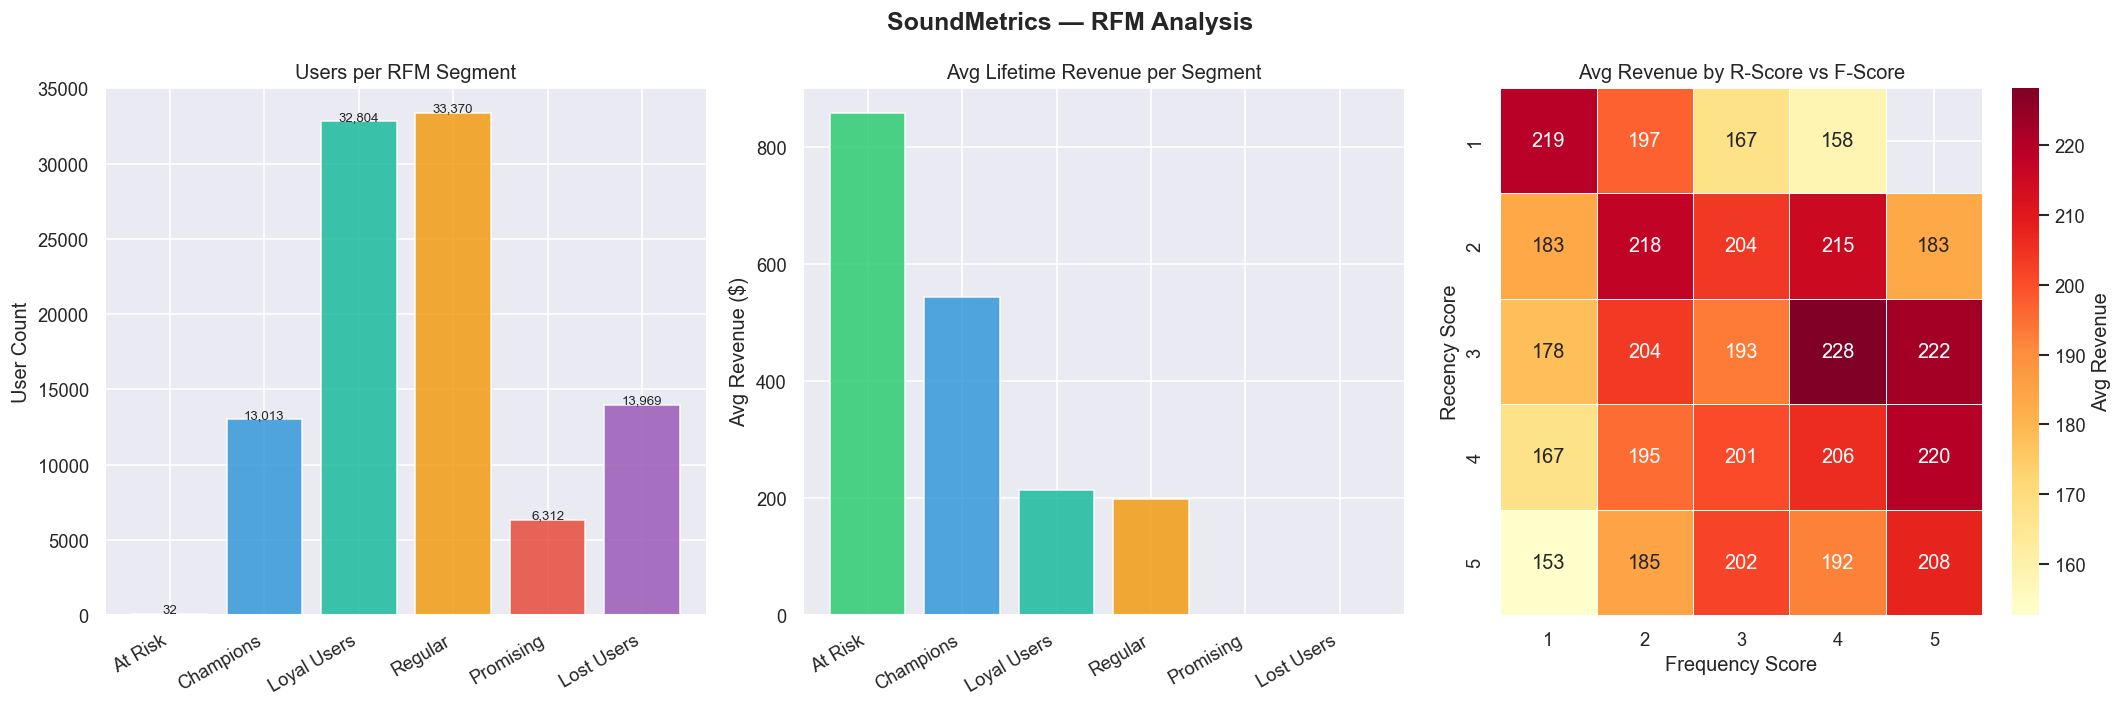

✅ Chart saved!


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

seg_order  = rfm_summary['rfm_segment'].tolist()
seg_colors = ['#2ecc71','#3498db','#1abc9c','#f39c12','#e74c3c','#9b59b6']

axes[0].bar(rfm_summary['rfm_segment'], rfm_summary['user_count'],
             color=seg_colors[:len(rfm_summary)], alpha=0.85)
axes[0].set_xticklabels(rfm_summary['rfm_segment'], rotation=30, ha='right')
axes[0].set_title('Users per RFM Segment')
axes[0].set_ylabel('User Count')
for bar, val in zip(axes[0].patches, rfm_summary['user_count']):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+100,
                  f'{val:,}', ha='center', fontsize=8)

axes[1].bar(rfm_summary['rfm_segment'], rfm_summary['avg_revenue'],
             color=seg_colors[:len(rfm_summary)], alpha=0.85)
axes[1].set_xticklabels(rfm_summary['rfm_segment'], rotation=30, ha='right')
axes[1].set_title('Avg Lifetime Revenue per Segment')
axes[1].set_ylabel('Avg Revenue ($)')

rfm_pivot = rfm.groupby(['r_score','f_score'])['lifetime_revenue'].mean().unstack()
sns.heatmap(rfm_pivot, ax=axes[2], cmap='YlOrRd', annot=True,
             fmt='.0f', linewidths=0.5, cbar_kws={'label':'Avg Revenue'})
axes[2].set_title('Avg Revenue by R-Score vs F-Score')
axes[2].set_xlabel('Frequency Score')
axes[2].set_ylabel('Recency Score')

plt.suptitle('SoundMetrics — RFM Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('data/charts/12_rfm_analysis.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Chart saved!')

In [12]:
ML_FEATURES = [
    'days_since_last_play',
    'total_plays',
    'avg_listen_duration',
    'skip_rate',
    'unique_genres',
    'repeat_rate',
    'lifetime_revenue',
    'failed_payments',
    'support_tickets',
]

ml_df = feature_df[feature_df['total_plays'] > 0].copy()
X_raw = ml_df[ML_FEATURES].copy()

print(f'Users included in clustering: {len(ml_df):,}')
print(f'Features used               : {len(ML_FEATURES)}')
print(f'\nFeature stats before scaling:')
print(X_raw.describe().round(2).to_string())

Users included in clustering: 83,816
Features used               : 9

Feature stats before scaling:
       days_since_last_play  total_plays  avg_listen_duration  skip_rate  unique_genres  repeat_rate  lifetime_revenue  failed_payments  support_tickets
count              83816.00     83816.00             83816.00   83816.00       83816.00     83816.00          83816.00         83816.00         83816.00
mean                 661.59        14.09               153.23      18.09           9.47         8.03            206.56             0.07             0.17
std                  301.49        11.18                39.91      16.73           5.58        11.82            964.79             0.26             0.42
min                  430.00         1.00                 0.00       0.00           1.00         0.00              0.00             0.00             0.00
25%                  474.00         6.00               134.30       7.14           5.00         0.00              0.00             0.00

In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

X_scaled_df = pd.DataFrame(X_scaled, columns=ML_FEATURES, index=X_raw.index)

print('After scaling — all columns should be close to mean=0, std=1:')
print(X_scaled_df.describe().round(2).to_string())

After scaling — all columns should be close to mean=0, std=1:
       days_since_last_play  total_plays  avg_listen_duration  skip_rate  unique_genres  repeat_rate  lifetime_revenue  failed_payments  support_tickets
count              83816.00     83816.00             83816.00   83816.00       83816.00     83816.00          83816.00         83816.00         83816.00
mean                   0.00        -0.00                 0.00      -0.00           0.00         0.00             -0.00             0.00             0.00
std                    1.00         1.00                 1.00       1.00           1.00         1.00              1.00             1.00             1.00
min                   -0.77        -1.17                -3.84      -1.08          -1.52        -0.68             -0.21            -0.25            -0.41
25%                   -0.62        -0.72                -0.47      -0.65          -0.80        -0.68             -0.21            -0.25            -0.41
50%                 

In [14]:
K_RANGE    = range(2, 10)
inertias   = []
sil_scores = []

print('Testing K values... (this will take 2-3 minutes)')
for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled, labels, sample_size=5000, random_state=42)
    sil_scores.append(sil)
    print(f'  K={k}  inertia={km.inertia_:>12,.0f}  silhouette={sil:.4f}')

print('\nDone!')

Testing K values... (this will take 2-3 minutes)


  File "c:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\ProgramData\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\ProgramData\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\ProgramData\anaconda3\Lib\subprocess.

  K=2  inertia=     628,354  silhouette=0.1731
  K=3  inertia=     554,513  silhouette=0.2019
  K=4  inertia=     486,946  silhouette=0.2203
  K=5  inertia=     436,704  silhouette=0.2268
  K=6  inertia=     386,476  silhouette=0.2361
  K=7  inertia=     340,764  silhouette=0.2728
  K=8  inertia=     307,341  silhouette=0.2783
  K=9  inertia=     282,956  silhouette=0.2475

Done!


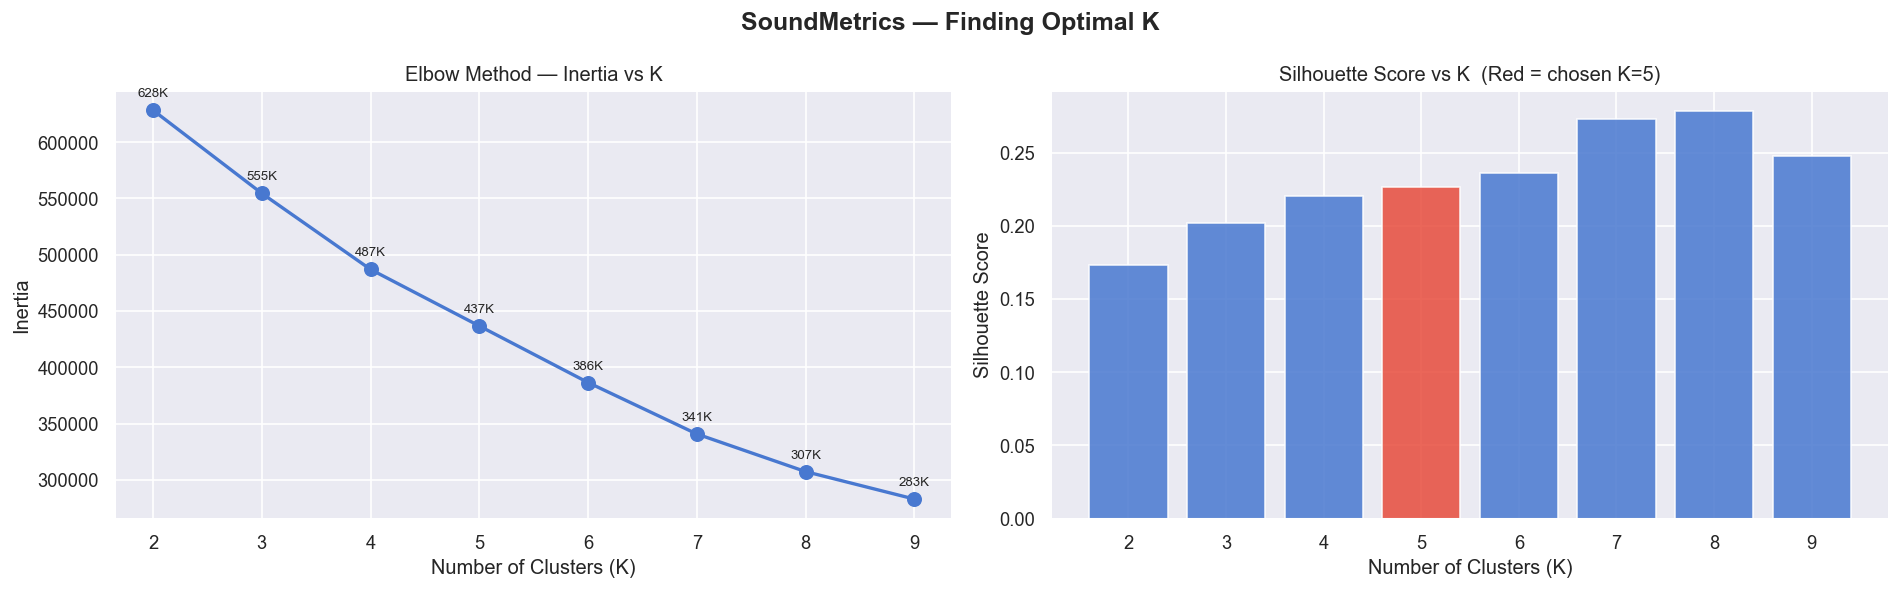

✅ Chart saved! Chosen K=5


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(list(K_RANGE), inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method — Inertia vs K')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].set_xticks(list(K_RANGE))
for k, inertia in zip(K_RANGE, inertias):
    axes[0].annotate(f'{inertia/1000:.0f}K', (k, inertia),
                      textcoords='offset points', xytext=(0,8),
                      ha='center', fontsize=8)

best_k     = 5
bar_colors = ['#e74c3c' if k == best_k else sns.color_palette('muted')[0]
               for k in K_RANGE]
axes[1].bar(list(K_RANGE), sil_scores, color=bar_colors, alpha=0.85)
axes[1].set_title(f'Silhouette Score vs K  (Red = chosen K={best_k})')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(list(K_RANGE))

plt.suptitle('SoundMetrics — Finding Optimal K', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('data/charts/13_optimal_k.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'✅ Chart saved! Chosen K=5')

In [16]:
FINAL_K = 5

kmeans = KMeans(
    n_clusters   = FINAL_K,
    n_init       = 20,
    max_iter     = 500,
    random_state = 42
)

ml_df['cluster'] = kmeans.fit_predict(X_scaled)

print(f'K-Means fitted with K={FINAL_K}')
print(f'Final inertia: {kmeans.inertia_:,.0f}')
print(f'\nCluster sizes:')
print(ml_df['cluster'].value_counts().sort_index())

K-Means fitted with K=5
Final inertia: 436,704

Cluster sizes:
cluster
0    42485
1     5188
2    16481
3    14598
4     5064
Name: count, dtype: int64


In [17]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
print(f'Variance explained by PC1: {explained[0]*100:.1f}%')
print(f'Variance explained by PC2: {explained[1]*100:.1f}%')
print(f'Total variance captured  : {sum(explained)*100:.1f}%')

Variance explained by PC1: 26.0%
Variance explained by PC2: 19.5%
Total variance captured  : 45.5%


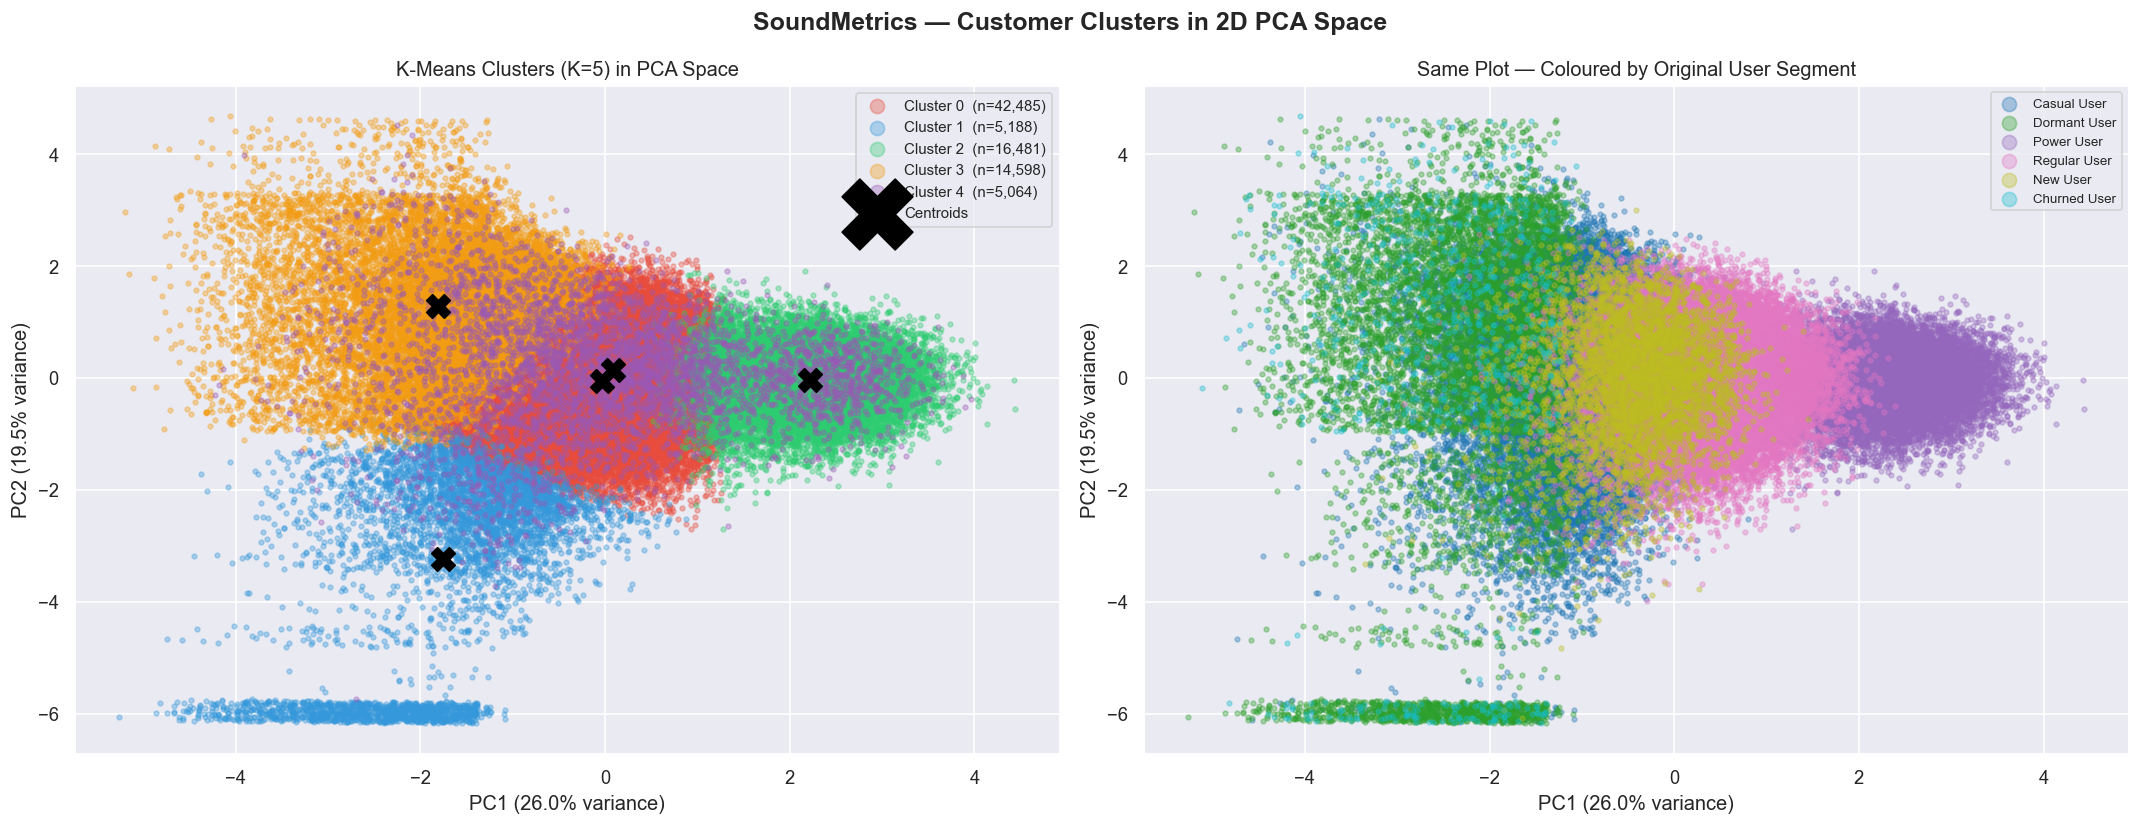

✅ Chart saved!


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

cluster_colors = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6']

for cluster_id in range(FINAL_K):
    mask = ml_df['cluster'] == cluster_id
    axes[0].scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=cluster_colors[cluster_id],
        label=f'Cluster {cluster_id}  (n={mask.sum():,})',
        alpha=0.35, s=8
    )
centroids_pca = pca.transform(kmeans.cluster_centers_)
axes[0].scatter(centroids_pca[:, 0], centroids_pca[:, 1],
                 c='black', marker='X', s=200, zorder=5, label='Centroids')
axes[0].set_title(f'K-Means Clusters (K={FINAL_K}) in PCA Space')
axes[0].set_xlabel(f'PC1 ({explained[0]*100:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({explained[1]*100:.1f}% variance)')
axes[0].legend(fontsize=9, markerscale=3)

segments   = ml_df['user_segment'].unique()
seg_colors = plt.cm.tab10(np.linspace(0, 1, len(segments)))
for seg, col in zip(segments, seg_colors):
    mask = ml_df['user_segment'] == seg
    axes[1].scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=[col], label=seg, alpha=0.35, s=8
    )
axes[1].set_title('Same Plot — Coloured by Original User Segment')
axes[1].set_xlabel(f'PC1 ({explained[0]*100:.1f}% variance)')
axes[1].set_ylabel(f'PC2 ({explained[1]*100:.1f}% variance)')
axes[1].legend(fontsize=8, markerscale=3)

plt.suptitle('SoundMetrics — Customer Clusters in 2D PCA Space',
              fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('data/charts/14_cluster_pca.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Chart saved!')

In [19]:
profile_cols = ML_FEATURES + ['cluster']
cluster_profile = (
    ml_df[profile_cols]
    .groupby('cluster')
    .mean()
    .round(2)
)
cluster_profile['user_count'] = ml_df.groupby('cluster').size()
cluster_profile['pct_of_users'] = (cluster_profile['user_count'] /
                                    len(ml_df) * 100).round(1)

print('CLUSTER PROFILES:')
print(cluster_profile.to_string())

CLUSTER PROFILES:
         days_since_last_play  total_plays  avg_listen_duration  skip_rate  unique_genres  repeat_rate  lifetime_revenue  failed_payments  support_tickets  user_count  pct_of_users
cluster                                                                                                                                                                             
0                      576.09        11.65               150.85      18.01           9.02         7.46            198.21             0.00             0.11       42485          50.7
1                      930.73         3.91                70.46      61.62           3.52         7.03            167.22             0.02             0.28        5188           6.2
2                      493.76        32.53               153.53      17.96          17.77         7.96            196.53             0.00             0.12       16481          19.7
3                     1011.74         3.85               188.46       3.55   

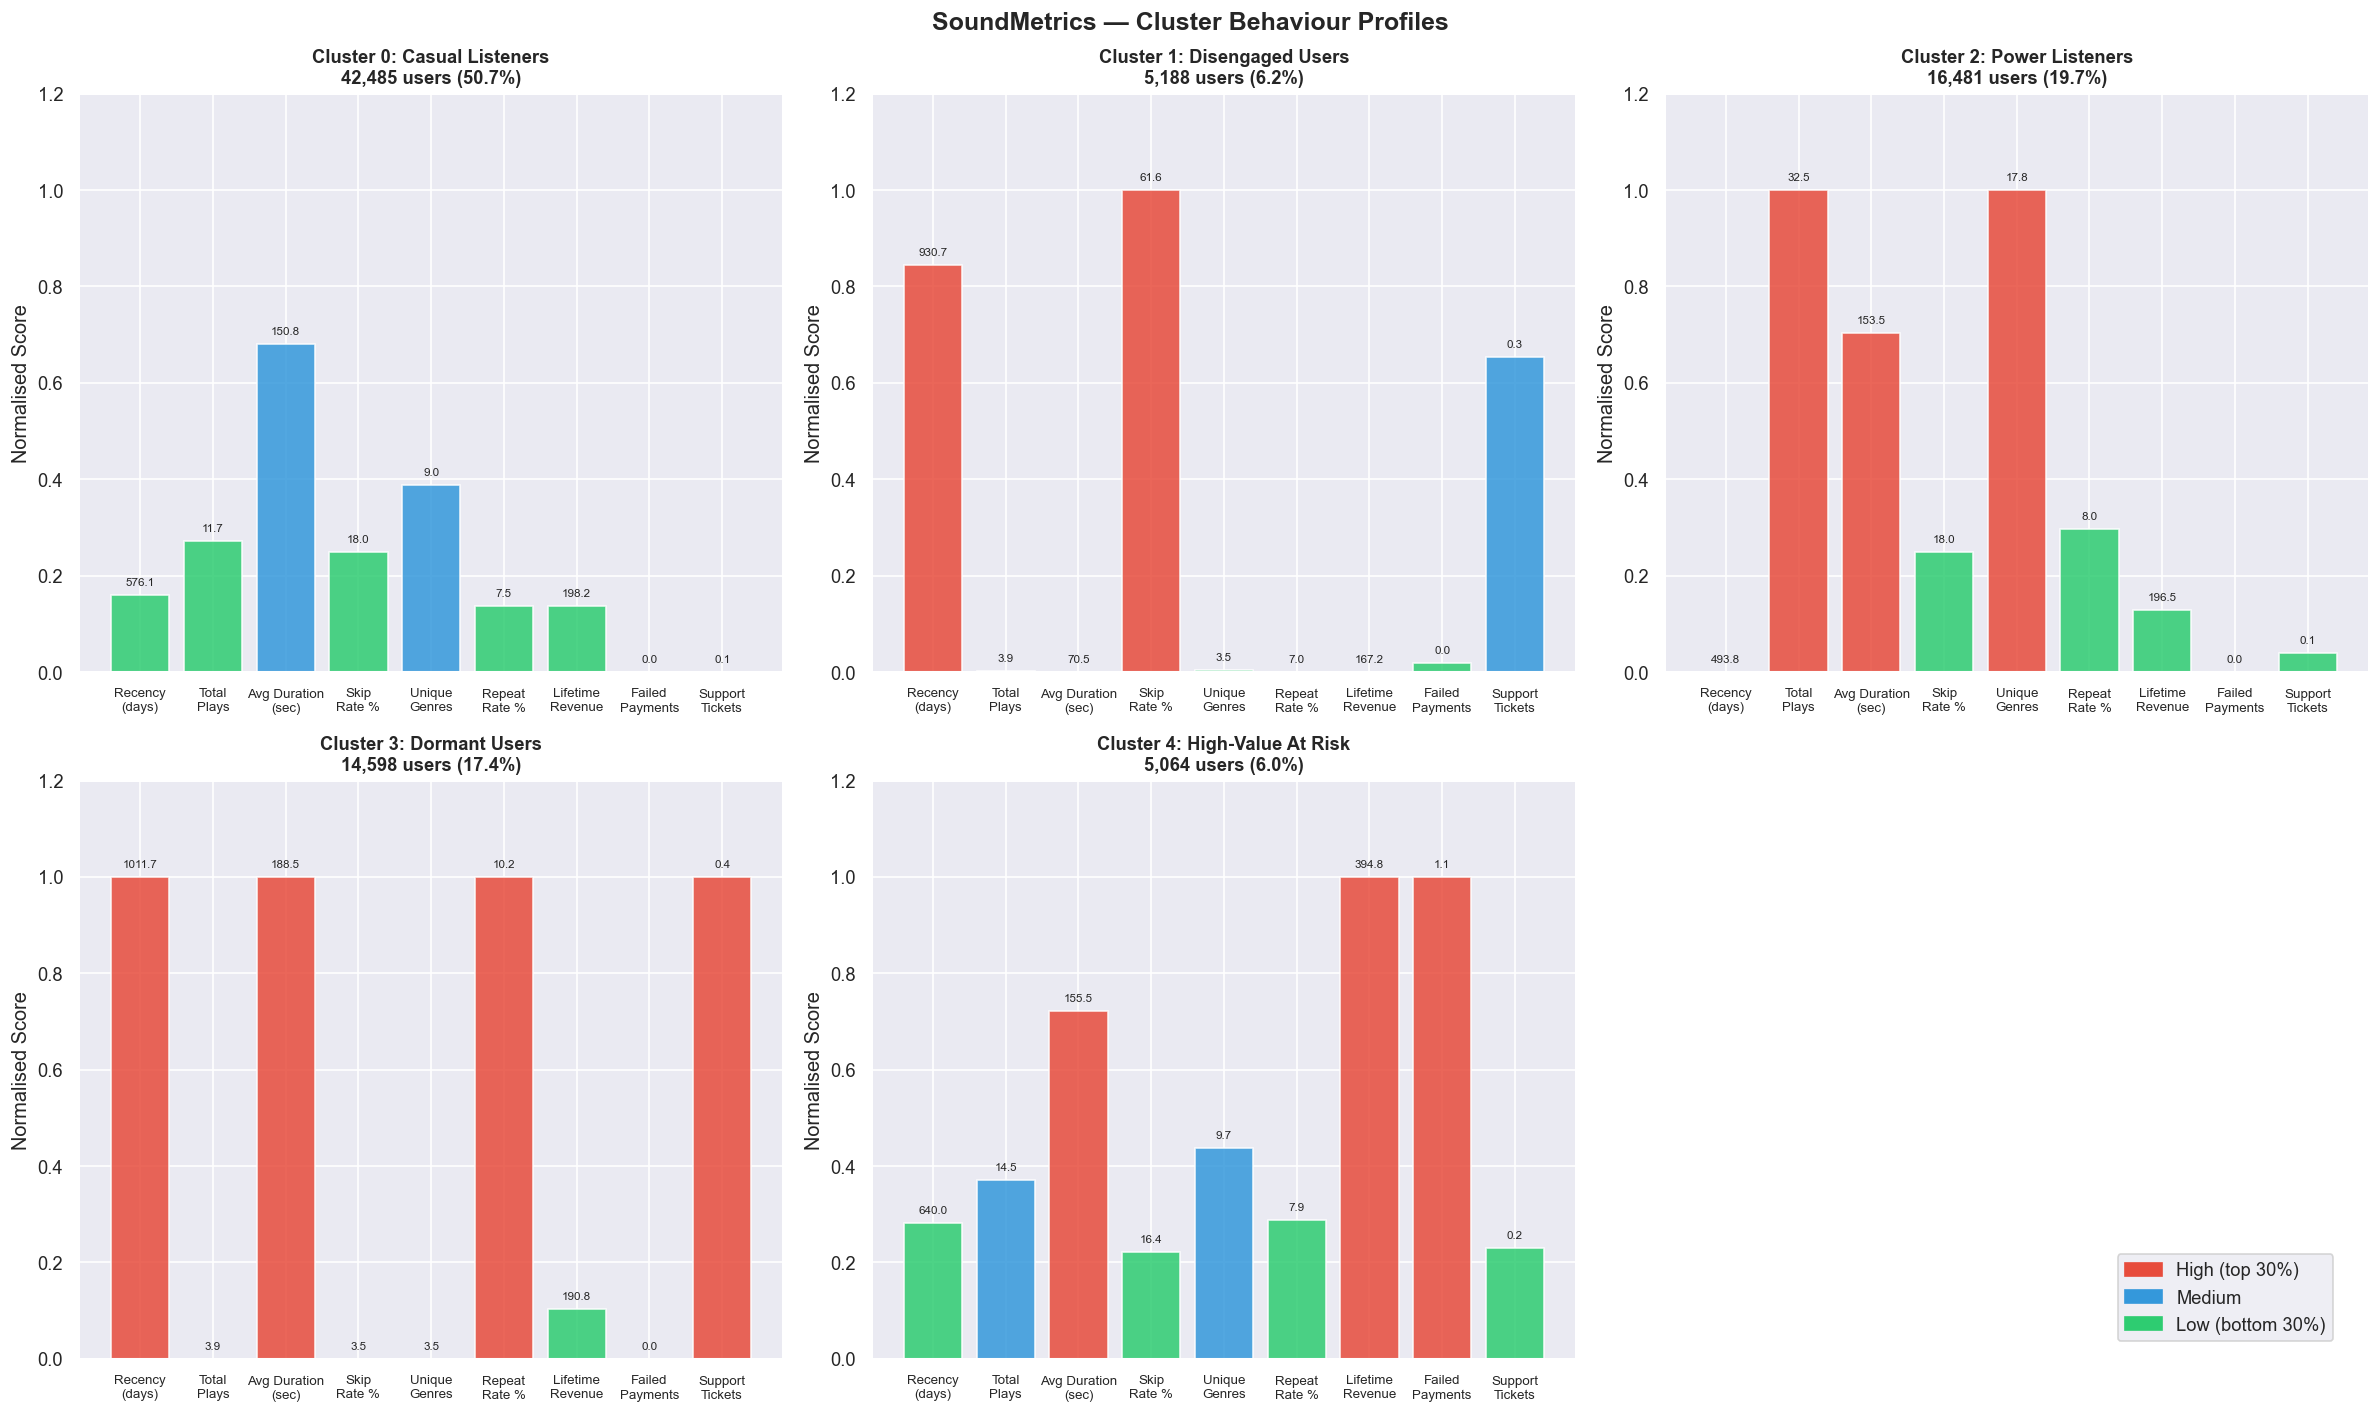

✅ Chart saved!


In [20]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

cluster_names = {
    0: 'Casual Listeners',
    1: 'Disengaged Users',
    2: 'Power Listeners',
    3: 'Dormant Users',
    4: 'High-Value At Risk'
}

norm_profile = cluster_profile[ML_FEATURES].copy()
for col in ML_FEATURES:
    col_min = norm_profile[col].min()
    col_max = norm_profile[col].max()
    if col_max > col_min:
        norm_profile[col] = (norm_profile[col] - col_min) / (col_max - col_min)

feature_labels = [
    'Recency\n(days)', 'Total\nPlays', 'Avg Duration\n(sec)',
    'Skip\nRate %', 'Unique\nGenres', 'Repeat\nRate %',
    'Lifetime\nRevenue', 'Failed\nPayments', 'Support\nTickets'
]

for i in range(FINAL_K):
    vals   = norm_profile.loc[i].values
    colors = ['#e74c3c' if v > 0.7 else '#2ecc71' if v < 0.3
               else '#3498db' for v in vals]
    bars   = axes[i].bar(feature_labels, vals, color=colors, alpha=0.85)
    axes[i].set_title(
        f'Cluster {i}: {cluster_names[i]}\n'
        f'{int(cluster_profile.loc[i,"user_count"]):,} users '
        f'({cluster_profile.loc[i,"pct_of_users"]:.1f}%)',
        fontweight='bold', fontsize=11
    )
    axes[i].set_ylim(0, 1.2)
    axes[i].set_ylabel('Normalised Score')
    axes[i].tick_params(axis='x', labelsize=8)
    raw_vals = cluster_profile[ML_FEATURES].loc[i].values
    for bar, raw in zip(bars, raw_vals):
        axes[i].text(bar.get_x()+bar.get_width()/2,
                      bar.get_height()+0.02,
                      f'{raw:.1f}', ha='center', fontsize=7)

# Hide the 6th subplot
axes[5].axis('off')

legend_patches = [
    mpatches.Patch(color='#e74c3c', label='High (top 30%)'),
    mpatches.Patch(color='#3498db', label='Medium'),
    mpatches.Patch(color='#2ecc71', label='Low (bottom 30%)'),
]
fig.legend(handles=legend_patches, loc='lower right',
            ncol=1, fontsize=11, bbox_to_anchor=(0.98, 0.05))

plt.suptitle('SoundMetrics — Cluster Behaviour Profiles',
              fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('data/charts/15_cluster_profiles.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Chart saved!')

In [ ]:
ml_df['cluster_name'] = ml_df['cluster'].map({
    0: 'Casual Listeners',
    1: 'Disengaged Users',
    2: 'Power Listeners',
    3: 'Dormant Users',
    4: 'High-Value At Risk'
})

rfm_export     = rfm[['user_id','r_score','f_score','m_score','rfm_total','rfm_segment']].copy()
cluster_export = ml_df[['user_id','cluster','cluster_name']].copy()

final_export = feature_df.copy()
final_export = final_export.merge(rfm_export,     on='user_id', how='left')
final_export = final_export.merge(cluster_export, on='user_id', how='left')

final_export['cluster']      = final_export['cluster'].fillna(-1).astype(int)
final_export['cluster_name'] = final_export['cluster_name'].fillna('No Activity')
final_export['rfm_segment']  = final_export['rfm_segment'].fillna('Inactive')

out_path = 'data/exports/soundmetrics_ml_output.csv'
final_export.to_csv(out_path, index=False)
a
print(f'✅ Export saved: {out_path}')
print(f'   Shape: {final_export.shape[0]:,} rows x {final_export.shape[1]} columns')
print(f'\nCluster distribution:')
print(final_export['cluster_name'].value_counts().to_string())
print(f'\nRFM distribution:')
print(final_export['rfm_segment'].value_counts().to_string())

✅ Export saved: data/exports/soundmetrics_ml_output.csv
   Shape: 99,500 rows x 29 columns

Cluster distribution:
cluster_name
Casual Listeners      42485
Power Listeners       16481
No Activity           15684
Dormant Users         14598
Disengaged Users       5188
High-Value At Risk     5064

RFM distribution:
rfm_segment
Regular        33370
Loyal Users    32804
Lost Users     13969
Champions      13013
Promising       6312
At Risk           32
